In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset


path

In [5]:
import os
img_classes=os.path.join(path,'IMG_CLASSES')

In [6]:
os.listdir(img_classes)

['1. Eczema 1677',
 '10. Warts Molluscum and other Viral Infections - 2103',
 '4. Basal Cell Carcinoma (BCC) 3323',
 '7. Psoriasis pictures Lichen Planus and related diseases - 2k',
 '5. Melanocytic Nevi (NV) - 7970',
 '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k',
 '3. Atopic Dermatitis - 1.25k',
 '6. Benign Keratosis-like Lesions (BKL) 2624',
 '8. Seborrheic Keratoses and other Benign Tumors - 1.8k',
 '2. Melanoma 15.75k']

In [7]:
batches=48
img_size=(380,380)

In [8]:
import tensorflow as tf
dataset=tf.keras.utils.image_dataset_from_directory(
    img_classes,
    image_size=img_size,
    batch_size=batches,
    shuffle=True

)

Found 27153 files belonging to 10 classes.


In [9]:
classes=dataset.class_names

In [52]:
import matplotlib.pyplot as plt


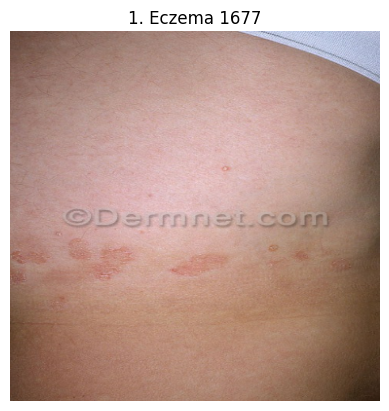

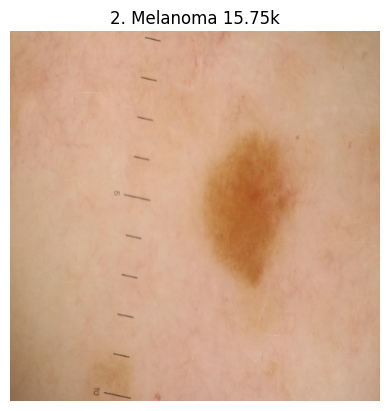

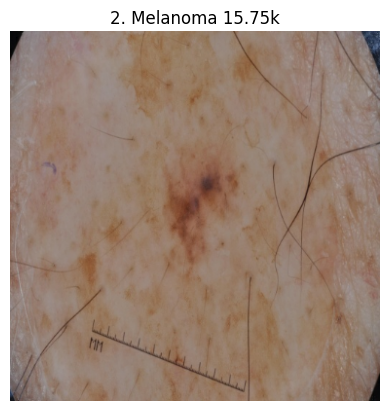

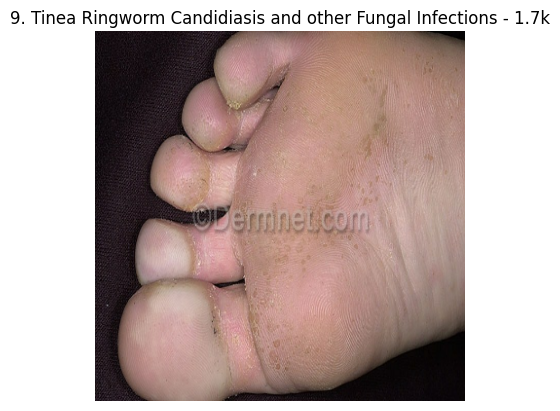

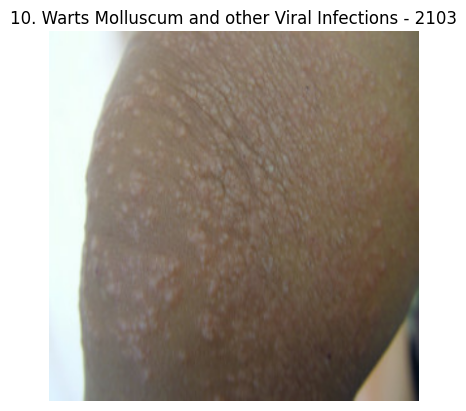

In [9]:
for images, labels in dataset.take(5):
  plt.imshow(images[1].numpy().astype("uint8"))

  plt.title(classes[labels[1].numpy()])
  plt.axis('off')
  plt.show()

In [14]:
from tensorflow import keras

In [15]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.2),
    keras.layers.RandomZoom(0.2),
])

In [16]:
import tensorflow as tf
from tensorflow import keras


In [17]:
train_size = int(0.8 * len(dataset))
remaining_batches = dataset.skip(train_size)
test_size=len(dataset)-train_size
# test_size here refers to the total number of batches in remaining_batches (114)
d = int(test_size / 2) # This will be 57

train_ds = dataset.take(train_size)
val_ds = remaining_batches.take(d) # First 57 batches for validation
test_ds = remaining_batches.skip(d) # Next 57 batches for testing

In [18]:
import numpy as np

y_train = []

for images, labels in train_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

In [19]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.6276069017254313), 1: np.float64(1.2937388193202146), 2: np.float64(0.8528301886792453), 3: np.float64(2.131237721021611), 4: np.float64(0.8243161094224924), 5: np.float64(0.343562945368171), 6: np.float64(1.3117291414752117), 7: np.float64(1.306987951807229), 8: np.float64(1.4649561107359892), 9: np.float64(1.5698986975397975)}


In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

inputs = keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)

bm = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_tensor=x,
)

bm.trainable = False

x = bm.output
x = layers.GlobalAveragePooling2D()(bm.output)

x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)

outputs = layers.Dense(len(classes), activation="softmax")(x)

model2 = keras.Model(inputs, outputs)

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [58]:
print(train_size,d)

452 57


In [21]:
AUTOTUNE = tf.data.AUTOTUNE
from tensorflow.keras.applications.efficientnet import preprocess_input

x = preprocess_input(x)
def process(x, y):
    # Removed preprocess_input(x) from here
    x = preprocess_input(x)
    return x, y

train_ds = train_ds.map(process).prefetch(AUTOTUNE)
val_ds = val_ds.map(process).prefetch(AUTOTUNE)

In [22]:
model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10


E0000 00:00:1775045978.536493      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1775045982.435441     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


452/452 ━━━━━━━━━━━━━━━━━━━━ 304s 621ms/step - accuracy: 0.3677 - loss: 2.1059 - val_accuracy: 0.6224 - val_loss: 0.9823
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 274s 606ms/step - accuracy: 0.5464 - loss: 1.3756 - val_accuracy: 0.6458 - val_loss: 0.9112
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 275s 609ms/step - accuracy: 0.5752 - loss: 1.2673 - val_accuracy: 0.6718 - val_loss: 0.8676
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 275s 608ms/step - accuracy: 0.6059 - loss: 1.1894 - val_accuracy: 0.6663 - val_loss: 0.8520
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 275s 608ms/step - accuracy: 0.6177 - loss: 1.1356 - val_accuracy: 0.6831 - val_loss: 0.8277
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 273s 605ms/step - accuracy: 0.6295 - loss: 1.1178 - val_accuracy: 0.6963 - val_loss: 0.7942
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 274s 605ms/step - accuracy: 0.6427 - loss: 1.0635 - val_accuracy: 0.7007 - val_loss: 0.7871
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 274s 605ms/step - accuracy: 0.6531 - loss: 1.05

In [29]:


from tensorflow import keras
from tensorflow.keras import layers

bm.trainable = True

for layer in bm.layers[:-80]:
    layer.trainable = False

model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]


In [31]:

# 4. Train (Fine-tuning)
history_finetune = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,   # if you computed it
    callbacks=callbacks
)



Epoch 1/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 319s 706ms/step - accuracy: 0.8667 - loss: 0.4074 - val_accuracy: 0.8107 - val_loss: 0.5714 - learning_rate: 3.0000e-05
Epoch 2/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 314s 695ms/step - accuracy: 0.8757 - loss: 0.3811 - val_accuracy: 0.8158 - val_loss: 0.5536 - learning_rate: 3.0000e-05
Epoch 3/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 314s 695ms/step - accuracy: 0.8771 - loss: 0.3753 - val_accuracy: 0.8136 - val_loss: 0.5622 - learning_rate: 3.0000e-05
Epoch 4/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 314s 695ms/step - accuracy: 0.8812 - loss: 0.3615 - val_accuracy: 0.8209 - val_loss: 0.5455 - learning_rate: 3.0000e-05
Epoch 5/5
452/452 ━━━━━━━━━━━━━━━━━━━━ 314s 695ms/step - accuracy: 0.8865 - loss: 0.3474 - val_accuracy: 0.8176 - val_loss: 0.5555 - learning_rate: 3.0000e-05


In [32]:
# 5. Evaluate on test set
test_loss, test_acc = model2.evaluate(test_ds)

print(f"Test Accuracy after fine-tuning: {test_acc:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 427ms/step - accuracy: 0.8208 - loss: 0.5325
Test Accuracy after fine-tuning: 0.8126


In [ ]:
model2.save('final.keras')

In [ ]:
path='/content/Ben.png'

In [ ]:
classes= [
    "Eczema",
    "Warts",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma",
    "Melanocytic Nevi",
    "Benign Keratosis",
    "Psoriasis / Lichen Planus",
    "Seborrheic Keratosis",
    "Tinea / Fungal Infection"
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Predicted: Atopic Dermatitis
Confidence: 0.7297197


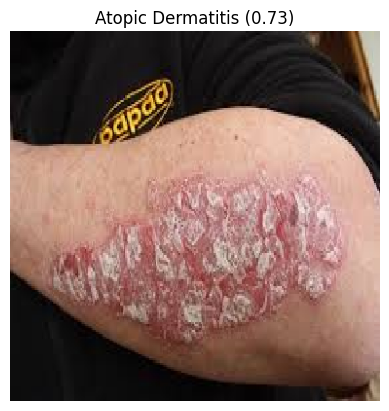

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ✅ Load model
model = tf.keras.models.load_model('/content/final.keras')

# ✅ Class names (⚠️ MUST match training)
class_names =classes # 🔥 REPLACE THIS

# ✅ Image path
img_path = '/content/Pso.jpg'

# 🔹 Load and show image
img = image.load_img(img_path, target_size=(380, 380))  # same size as training
plt.imshow(img)
plt.axis('off')

# 🔹 Preprocess
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

# 🔹 Predict
predictions = model.predict(img_array)

# 🔹 Result
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

print("Predicted:", predicted_class)
print("Confidence:", confidence)

plt.title(f"{predicted_class} ({confidence:.2f})")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 

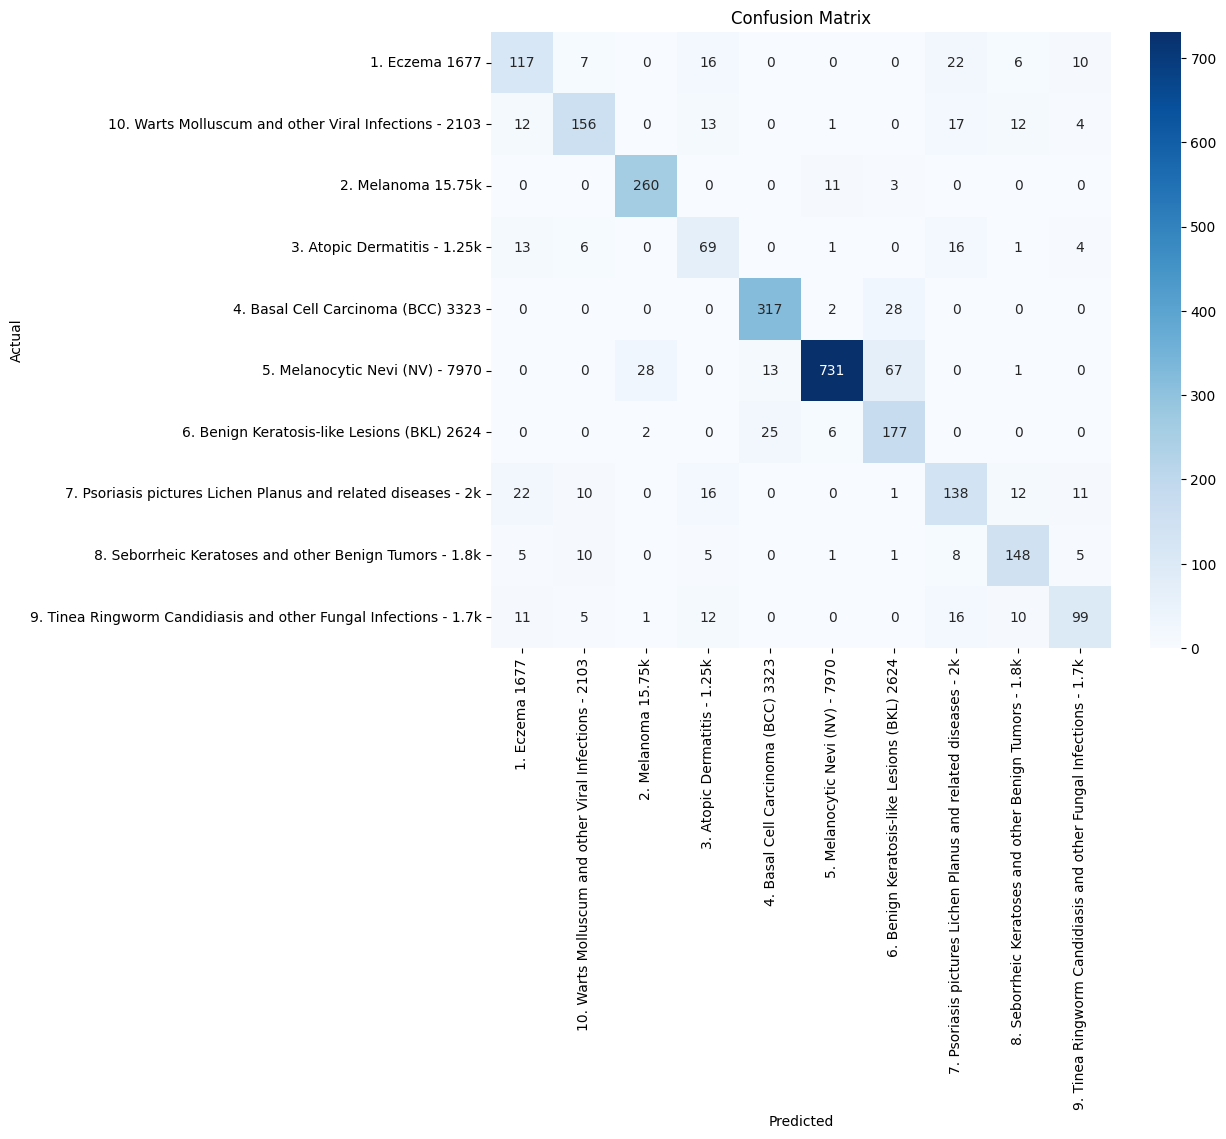


Classification Report:

                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.65      0.66      0.65       178
           10. Warts Molluscum and other Viral Infections - 2103       0.80      0.73      0.76       215
                                              2. Melanoma 15.75k       0.89      0.95      0.92       274
                                    3. Atopic Dermatitis - 1.25k       0.53      0.63      0.57       110
                              4. Basal Cell Carcinoma (BCC) 3323       0.89      0.91      0.90       347
                                 5. Melanocytic Nevi (NV) - 7970       0.97      0.87      0.92       840
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.64      0.84      0.73       210
   7. Psoriasis pictures Lichen Planus and related diseases - 2k       0.64      0.66      0.65       210
          8. Seborrh

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

# 🔹 Get predictions
for images, labels in test_ds:
    preds = model2.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 🔹 Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 🔹 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 🔹 Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🔹 Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))

In [ ]:


final = tf.keras.models.load_model('/content/final.keras')


In [28]:
model2.save("final5.keras")

In [ ]:
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)
print("TensorFlow Lite model saved to 'model.tflite'")

TensorFlow Lite model saved to 'model.tflite'


In [ ]:
tflite_model.summary()

Buffered data was truncated after reaching the output size limit.